In [1]:
import pandas as pd

df = pd.read_csv('/kaggle/input/data-img-fake-real/features_handcraft_pca.csv')


In [2]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3417 entries, 0 to 3416
Columns: 513 entries, 0 to label
dtypes: float64(513)
memory usage: 13.4 MB


,0,1,2,3,4,5,6,7,8,9,...,503,504,505,506,507,508,509,510,511,label
0,-90.143431,-24.325168,5.851777,-49.331746,-45.560314,-57.787939,24.613754,-20.833134,-24.139192,3.723929,...,-4.841529,-3.914853,4.214789,4.396488,3.769170,1.022109,-5.691521,-1.478762,0.298144,0.0
1,-246.943273,16.497613,34.934814,-15.258153,5.523398,5.003261,6.357868,11.544529,3.026625,-11.592451,...,1.904592,2.632372,1.466434,0.549755,-2.078533,0.170460,-0.719524,4.873636,7.263614,0.0
2,-29.619168,47.129363,-1.247367,-11.214669,23.692716,22.134369,48.866019,-20.062487,-8.746344,-2.411041,...,-2.165896,0.563015,-3.813871,-3.625718,5.172486,-2.983125,-0.630621,-8.458762,-3.439649,0.0
3,-149.058454,104.578247,8.831053,-28.702627,-11.762134,-9.241918,2.795985,1.464393,9.225152,18.131857,...,-2.092509,4.676365,6.444659,-9.122905,-6.758287,-2.809508,-0.914393,2.142329,-0.661095,1.0
4,-204.176077,-24.776721,-28.521355,22.169255,8.870100,-5.937461,-7.946820,26.743526,13.094676,-12.407232,...,0.646175,0.564471,1.317015,-0.338480,0.807122,0.310969,-0.848134,-1.369522,-0.327078,1.0


In [3]:
X = df.drop('label', axis=1)
y = df['label']

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split


In [5]:
Xh_train, Xh_test, yh_train, yh_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Logistic

              precision    recall  f1-score   support

         0.0       0.79      0.79      0.79       517
         1.0       0.78      0.78      0.78       509

    accuracy                           0.78      1026
   macro avg       0.78      0.78      0.78      1026
weighted avg       0.78      0.78      0.78      1026



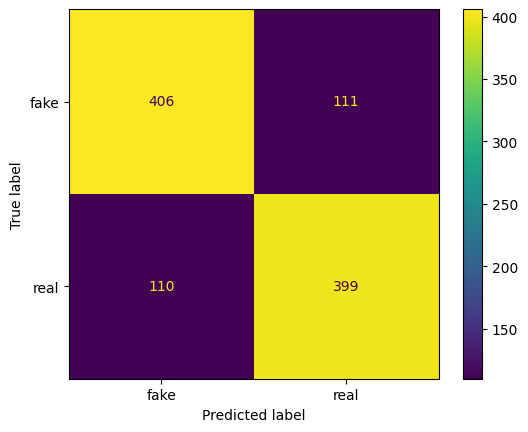

In [6]:
lgt_model = LogisticRegression(solver='newton-cholesky')
lgt_model.fit(Xh_train,yh_train)
y_pred = lgt_model.predict(Xh_test)

print(classification_report(yh_test, y_pred))
ConfusionMatrixDisplay(confusion_matrix(yh_test,y_pred),display_labels=['fake','real']).plot()


## cross-validation-lgt

In [7]:
from sklearn.model_selection import cross_val_score, KFold
import numpy as np

lgt_model = LogisticRegression(solver='newton-cholesky')

kf = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(lgt_model, Xh_train, yh_train, cv=kf, scoring='accuracy')

print(f"Accuracy từng fold: {scores}")
print(f"Mean accuracy: {np.mean(scores):.4f}")


Accuracy từng fold: [0.70981211 0.74476987 0.76778243 0.74267782 0.74895397]
Mean accuracy: 0.7428


# SVM

              precision    recall  f1-score   support

         0.0       0.82      0.86      0.84       517
         1.0       0.86      0.81      0.83       509

    accuracy                           0.84      1026
   macro avg       0.84      0.84      0.84      1026
weighted avg       0.84      0.84      0.84      1026



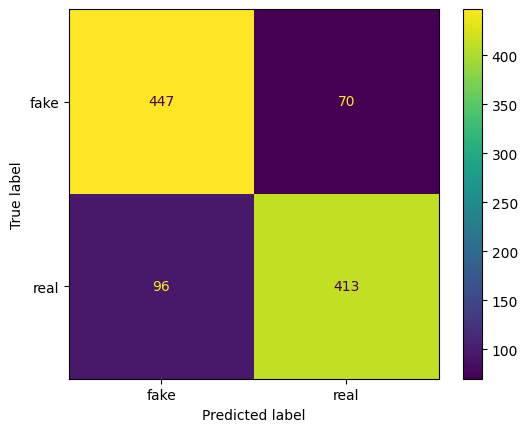

In [8]:
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf', C=1, gamma='scale')  

svm_model.fit(Xh_train, yh_train)

y_pred = svm_model.predict(Xh_test)

print(classification_report(yh_test, y_pred))
ConfusionMatrixDisplay(confusion_matrix(yh_test, y_pred), display_labels=['fake', 'real']).plot()


## save-model-svm

In [9]:
import joblib

joblib.dump(svm_model,'svm_model.pkl')

['svm_model.pkl']

## grid-search

Fitting 10 folds for each of 5 candidates, totalling 50 fits
best parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
              precision    recall  f1-score   support

         0.0       0.83      0.83      0.83       517
         1.0       0.83      0.83      0.83       509

    accuracy                           0.83      1026
   macro avg       0.83      0.83      0.83      1026
weighted avg       0.83      0.83      0.83      1026



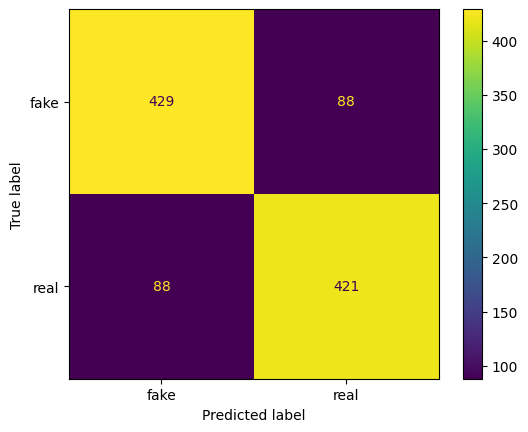

In [10]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],   
    'gamma': ['scale'],           
    'kernel': ['rbf']              
}

#GridSearchCV
grid = GridSearchCV(
    SVC(), 
    param_grid, 
    cv=10,             
    verbose=2,        
    n_jobs=-1         
)

grid.fit(Xh_train, yh_train)

print("best parameters:", grid.best_params_)

best_svm = grid.best_estimator_
y_pred = best_svm.predict(Xh_test)

print(classification_report(yh_test, y_pred))

ConfusionMatrixDisplay(confusion_matrix(yh_test, y_pred), display_labels=['fake', 'real']).plot()


# Random Forest

              precision    recall  f1-score   support

         0.0       0.77      0.84      0.80       517
         1.0       0.82      0.74      0.78       509

    accuracy                           0.79      1026
   macro avg       0.79      0.79      0.79      1026
weighted avg       0.79      0.79      0.79      1026



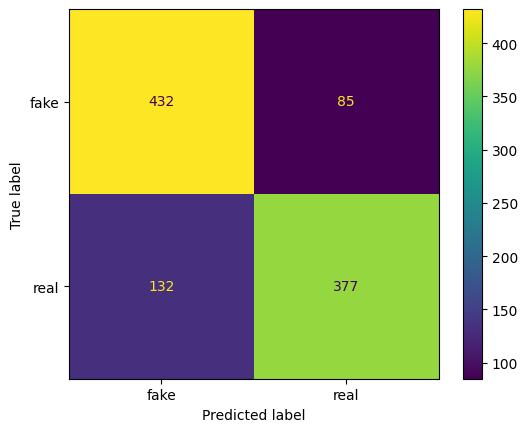

In [11]:
from sklearn.ensemble import RandomForestClassifier



rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(Xh_train, yh_train)

y_pred = rf_model.predict(Xh_test)

print(classification_report(yh_test, y_pred))

ConfusionMatrixDisplay(confusion_matrix(yh_test, y_pred), display_labels=['fake', 'real']).plot()


## grid-search

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Hyperparameters: {'max_depth': 20, 'n_estimators': 200}
              precision    recall  f1-score   support

        fake       0.81      0.82      0.81       517
        real       0.81      0.80      0.81       509

    accuracy                           0.81      1026
   macro avg       0.81      0.81      0.81      1026
weighted avg       0.81      0.81      0.81      1026



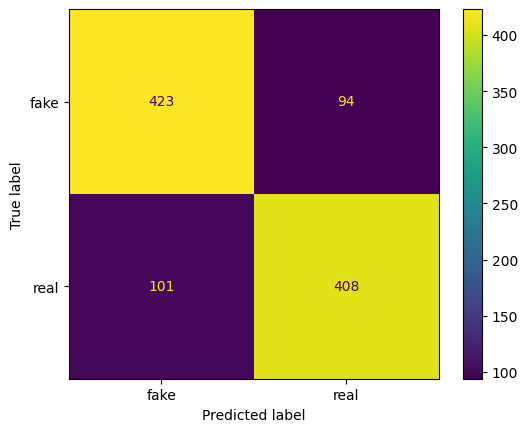

In [12]:
from sklearn.model_selection import GridSearchCV


param_grid = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [20, 50, 100, 150]
}

rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5, n_jobs=-1,
    verbose=2)
grid_search.fit(Xh_train, yh_train)

# model tốt nhất
best_rf = grid_search.best_estimator_
print("Best Hyperparameters:", grid_search.best_params_)

y_pred = best_rf.predict(Xh_test)
print(classification_report(yh_test, y_pred, target_names=['fake', 'real']))
ConfusionMatrixDisplay(confusion_matrix(yh_test, y_pred), display_labels=['fake','real']).plot()



# XGBoost

              precision    recall  f1-score   support

         0.0       0.85      0.85      0.85       517
         1.0       0.85      0.85      0.85       509

    accuracy                           0.85      1026
   macro avg       0.85      0.85      0.85      1026
weighted avg       0.85      0.85      0.85      1026



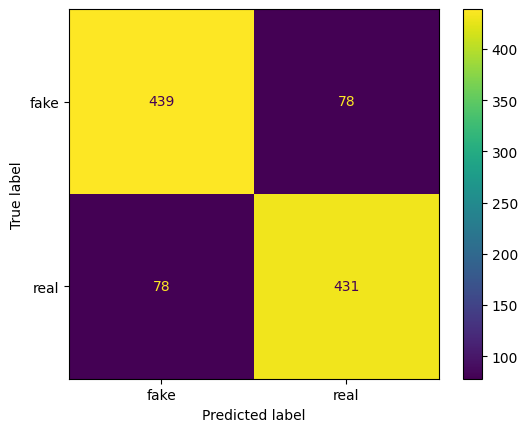

In [13]:
import numpy as np
import pandas as pd
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

xgb = XGBClassifier(
    n_estimators=100,         # Số cây 
    max_depth=6,              # Độ sâu của cây
    learning_rate=0.1,        
    subsample=0.8,            # Tỷ lệ mẫu mỗi cây
    colsample_bytree=0.8,     # Tỷ lệ cột mỗi cây
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

xgb.fit(Xh_train, yh_train)

y_pred = xgb.predict(Xh_test)

print(classification_report(yh_test, y_pred))
ConfusionMatrixDisplay(confusion_matrix(yh_test, y_pred), display_labels=['fake', 'real']).plot()

# MLP

              precision    recall  f1-score   support

        fake       0.83      0.82      0.83       517
        real       0.82      0.83      0.83       509

    accuracy                           0.83      1026
   macro avg       0.83      0.83      0.83      1026
weighted avg       0.83      0.83      0.83      1026



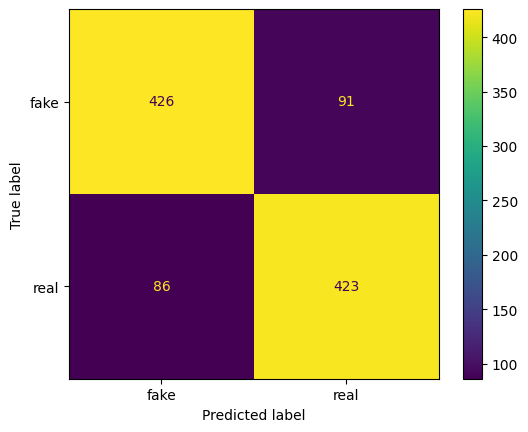

In [14]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(hidden_layer_sizes=(512, 240, 128), 
                    activation='relu',
                    solver='adam',
                    random_state=42,
                    max_iter=500)
mlp.fit(Xh_train, yh_train)

y_pred = mlp.predict(Xh_test)

print(classification_report(yh_test, y_pred, target_names=['fake', 'real']))
ConfusionMatrixDisplay(confusion_matrix(yh_test, y_pred), display_labels=['fake','real']).plot()